In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


In [3]:
df = pd.read_csv(r'D:/Análise_Empresas_Software/dataset_final.csv', dtype=str)

# Dicionário de situação cadastral
situacao_map = {
    '01': 'Nula',
    '02': 'Ativa',
    '03': 'Suspensa',
    '04': 'Inapta',
    '08': 'Baixada'
}

# Dicionário de CNAEs
cnae_map = {
    '6201500': 'Desenv. sob encomenda',
    '6201501': 'Desenv. sob encomenda',
    '6201502': 'Web design',
    '6202300': 'Software customizável',
    '6203100': 'Software não-customizável',
    '6204000': 'Consultoria em TI',
    '6209100': 'Suporte técnico/TI'
}

df['situacao_nome'] = df['situacao_cadastral'].map(situacao_map)
df['cnae_nome'] = df['cnae_fiscal_principal'].map(cnae_map)
df['ano_abertura'] = df['data_inicio_atividade'].str[:4]

print(f"Dataset carregado: {len(df):,} registros")
print(f"Colunas: {list(df.columns)}")

Dataset carregado: 480,677 registros
Colunas: ['cnpj_basico', 'cnpj_ordem', 'cnpj_dv', 'identificador_matriz_filial', 'nome_fantasia', 'situacao_cadastral', 'data_situacao_cadastral', 'motivo_situacao_cadastral', 'nome_cidade_exterior', 'pais', 'data_inicio_atividade', 'cnae_fiscal_principal', 'cnae_fiscal_secundaria', 'tipo_logradouro', 'logradouro', 'numero', 'complemento', 'bairro', 'cep', 'uf', 'municipio', 'ddd1', 'telefone1', 'ddd2', 'telefone2', 'ddd_fax', 'fax', 'correio_eletronico', 'situacao_especial', 'data_situacao_especial', 'opcao_simples', 'data_opcao_simples', 'data_exclusao_simples', 'opcao_mei', 'data_opcao_mei', 'data_exclusao_mei', 'situacao_nome', 'cnae_nome', 'ano_abertura']


# Análise do Setor de Software Brasileiro
## Projeto de Extensão — Estruture Negócios | UFPB 2026

**Fonte dos dados:** Receita Federal do Brasil — Dados Abertos CNPJ (fev/2026)  
**Datasets utilizados:**
- Estabelecimentos (10 arquivos) — CNAE, UF, município, situação cadastral, data de abertura
- Simples Nacional — regime tributário das empresas

**CNAEs considerados:**
| Código | Descrição |
|--------|-----------|
| 6201500/01 | Desenvolvimento de software sob encomenda |
| 6201502 | Web design |
| 6202300 | Desenvolvimento de software customizável |
| 6203100 | Desenvolvimento de software não-customizável |
| 6204000 | Consultoria em tecnologia da informação |
| 6209100 | Suporte técnico e manutenção em TI |

In [4]:
total = len(df)

print("=" * 55)
print("  SETOR DE SOFTWARE BRASILEIRO — fev/2026")
print("=" * 55)

print(f"\n{'Total de empresas':<35} {total:>10,}")
print(f"{'Estados cobertos':<35} {df['uf'].nunique():>10}")
print(f"{'Municípios cobertos':<35} {df['municipio'].nunique():>10,}")
print(f"{'Período de abertura':<35} {df['ano_abertura'].min()} – {df['ano_abertura'].max()}")

print("\n--- Situação Cadastral ---")
for k, v in df['situacao_nome'].value_counts().items():
    print(f"  {k:<20} {v:>8,}  ({v/total*100:.1f}%)")

print("\n--- Distribuição por CNAE ---")
for k, v in df['cnae_nome'].value_counts().items():
    print(f"  {k:<30} {v:>8,}  ({v/total*100:.1f}%)")

print("\n--- Simples Nacional ---")
for k, v in df['opcao_simples'].value_counts().items():
    label = 'Optante' if k == 'S' else 'Não optante'
    print(f"  {label:<20} {v:>8,}  ({v/total*100:.1f}%)")

print("\n--- Top 10 Estados ---")
for uf, v in df['uf'].value_counts().head(10).items():
    print(f"  {uf:<5} {v:>8,}  ({v/total*100:.1f}%)")

  SETOR DE SOFTWARE BRASILEIRO — fev/2026

Total de empresas                      480,677
Estados cobertos                            28
Municípios cobertos                      4,062
Período de abertura                 1923 – 2026

--- Situação Cadastral ---
  Ativa                 262,356  (54.6%)
  Baixada               174,303  (36.3%)
  Inapta                 40,097  (8.3%)
  Suspensa                3,481  (0.7%)
  Nula                      440  (0.1%)

--- Distribuição por CNAE ---
  Suporte técnico/TI              157,977  (32.9%)
  Consultoria em TI               115,847  (24.1%)
  Desenv. sob encomenda           113,957  (23.7%)
  Software customizável            46,492  (9.7%)
  Software não-customizável        39,239  (8.2%)
  Web design                        7,165  (1.5%)

--- Simples Nacional ---
  Não optante           286,229  (59.5%)
  Optante               194,448  (40.5%)

--- Top 10 Estados ---
  SP     235,869  (49.1%)
  MG      40,181  (8.4%)
  RJ      37,631  (7.

In [5]:
df.head(10)

,cnpj_basico,cnpj_ordem,cnpj_dv,identificador_matriz_filial,nome_fantasia,situacao_cadastral,data_situacao_cadastral,motivo_situacao_cadastral,nome_cidade_exterior,pais,...,data_situacao_especial,opcao_simples,data_opcao_simples,data_exclusao_simples,opcao_mei,data_opcao_mei,data_exclusao_mei,situacao_nome,cnae_nome,ano_abertura
0,81530685,0001,80,1,FOCUS TECNOLOGIA EM SAUDE,02,20051103,00,NaN,NaN,...,NaN,N,20170101,20221231,N,00000000,00000000,Ativa,Consultoria em TI,1993
1,45443082,0001,87,1,NaN,02,20050924,00,NaN,NaN,...,NaN,N,NaN,NaN,N,NaN,NaN,Ativa,Consultoria em TI,1981
2,07563461,0001,11,1,INFOCO INFORMATICA,08,20241205,01,NaN,NaN,...,NaN,N,20080101,20241205,N,00000000,00000000,Baixada,Suporte técnico/TI,2005
3,63288484,0001,36,1,STA INFORMATICA,02,20051103,00,NaN,NaN,...,NaN,N,NaN,NaN,N,NaN,NaN,Ativa,Consultoria em TI,1992
4,81633828,0001,89,1,SERIAL SISTEMAS,08,20150805,02,NaN,NaN,...,NaN,N,NaN,NaN,N,NaN,NaN,Baixada,Software não-customizável,1990
5,05517927,0001,17,1,NaN,02,20030106,00,NaN,023,...,NaN,N,NaN,NaN,N,NaN,NaN,Ativa,Software não-customizável,2003
6,03736981,0001,28,1,RAFAEL FOSSATI FRITSCH,08,20020528,01,NaN,NaN,...,NaN,N,NaN,NaN,N,NaN,NaN,Baixada,Consultoria em TI,2000
7,81779985,0001,05,1,NaN,08,20080912,01,NaN,NaN,...,NaN,N,NaN,NaN,N,NaN,NaN,Baixada,Consultoria em TI,1990
8,45792629,0001,50,1,NaN,04,20181023,63,NaN,NaN,...,NaN,N,NaN,NaN,N,NaN,NaN,Inapta,Suporte técnico/TI,1981
9,63372122,0005,52,2,NaN,08,20120920,01,NaN,NaN,...,NaN,N,NaN,NaN,N,NaN,NaN,Baixada,Suporte técnico/TI,2006


In [6]:
colunas_relevantes = [
    'cnpj_basico',
    'nome_fantasia', 
    'uf',
    'municipio',
    'situacao_nome',
    'cnae_nome',
    'ano_abertura',
    'opcao_simples',
    'opcao_mei'
]

df[colunas_relevantes].head(10)

,cnpj_basico,nome_fantasia,uf,municipio,situacao_nome,cnae_nome,ano_abertura,opcao_simples,opcao_mei
0,81530685,FOCUS TECNOLOGIA EM SAUDE,RS,8801,Ativa,Consultoria em TI,1993,N,N
1,45443082,NaN,SP,7047,Ativa,Consultoria em TI,1981,N,N
2,07563461,INFOCO INFORMATICA,RJ,6001,Baixada,Suporte técnico/TI,2005,N,N
3,63288484,STA INFORMATICA,BA,3683,Ativa,Consultoria em TI,1992,N,N
4,81633828,SERIAL SISTEMAS,SC,8105,Baixada,Software não-customizável,1990,N,N
5,05517927,NaN,EX,9707,Ativa,Software não-customizável,2003,N,N
6,03736981,RAFAEL FOSSATI FRITSCH,RS,8801,Baixada,Consultoria em TI,2000,N,N
7,81779985,NaN,SC,8179,Baixada,Consultoria em TI,1990,N,N
8,45792629,NaN,SP,7107,Inapta,Suporte técnico/TI,1981,N,N
9,63372122,NaN,CE,1389,Baixada,Suporte técnico/TI,2006,N,N


In [9]:
# Remover registros EX e salvar dataset limpo
df = df[df['uf'] != 'EX']

print(f"Dataset após remoção de EX: {len(df)} empresas")
print(f"UFs únicas restantes: {sorted(df['uf'].unique())}")

Dataset após remoção de EX: 479071 empresas
UFs únicas restantes: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


# Análise: Distribuição de Empresas de Software Ativas por UF

## Visão Geral

O gráfico revela uma concentração geográfica extrema do setor de software brasileiro,
com o Sudeste e Sul dominando de forma absoluta enquanto o Nordeste permanece
fragmentado e sub-representado.

---

## 1. Dominância do Sudeste/Sul

São Paulo (SP) lidera com enorme distância — visualmente, sua barra ultrapassa
120.000 empresas ativas, superando sozinho a soma de praticamente todos os demais
estados. O grupo formado por MG, PR, RJ, SC e RS ocupa as posições seguintes,
todas com barras entre 15.000 e 25.000 empresas, configurando um bloco coeso de
alta concentração nas regiões Sudeste e Sul.

O Distrito Federal (DF) aparece como exceção fora desse bloco, posicionado em 7º
lugar com cerca de 8.000 empresas — reflexo da concentração de órgãos públicos
e empresas de tecnologia voltadas ao governo federal.

---

## 2. O Nordeste no Contexto Nacional

Os estados nordestinos (destacados em coral) aparecem dispersos ao longo da metade
inferior do ranking, sem nenhum representante no top 7. Os três estados nordestinos
com maior presença são:

| UF | Posição no ranking | Observação |
|----|--------------------|------------|
| CE | 8º | Polo tecnológico regional mais consolidado |
| BA | 10º | Maior estado nordestino em população e PIB |
| PE | 11º | Hub de tecnologia do Recife (Porto Digital) |

A Paraíba (PB) aparece na 14ª posição, abaixo de estados como GO (Centro-Oeste)
e ES (Sudeste), evidenciando a limitação do ecossistema local — contexto direto
da narrativa do Carlos e da hipótese central do projeto.

---

## 3. Cauda Longa e Estados Periféricos

A partir de MT, a distribuição entra em uma longa cauda com barras quase
imperceptíveis. Estados como AC, AP e RR têm presença mínima, o que levanta
questões metodológicas para análises per capita: a baixa densidade populacional
pode distorcer métricas de proporção nesses casos.

---

## 4. Insight Principal para o Projeto

A distribuição confirma visualmente a hipótese de desigualdade regional do
**Estruture Negócios**: o Nordeste, com ~28% da população brasileira, concentra
uma fração desproporcional e pequena das empresas de software ativas. Nenhum
estado nordestino entra sequer no top 7 nacional, e os três mais representativos
(CE, BA, PE) têm volumes próximos — sem um polo dominante que concentre o
ecossistema regional.

---

## 5. Próximos Passos Sugeridos

- **Concentração relativa**: calcular a participação percentual Nordeste vs. Sudeste
  no total de empresas ativas
- **Análise por porte**: verificar se o Nordeste tem proporcionalmente mais MEIs e
  menos EPPs/MEs que o Sudeste — o que indicaria menor maturidade empresarial
- **Evolução temporal**: cruzar com `ano_abertura` para ver se a desigualdade está
  se ampliando ou reduzindo ao longo do tempo

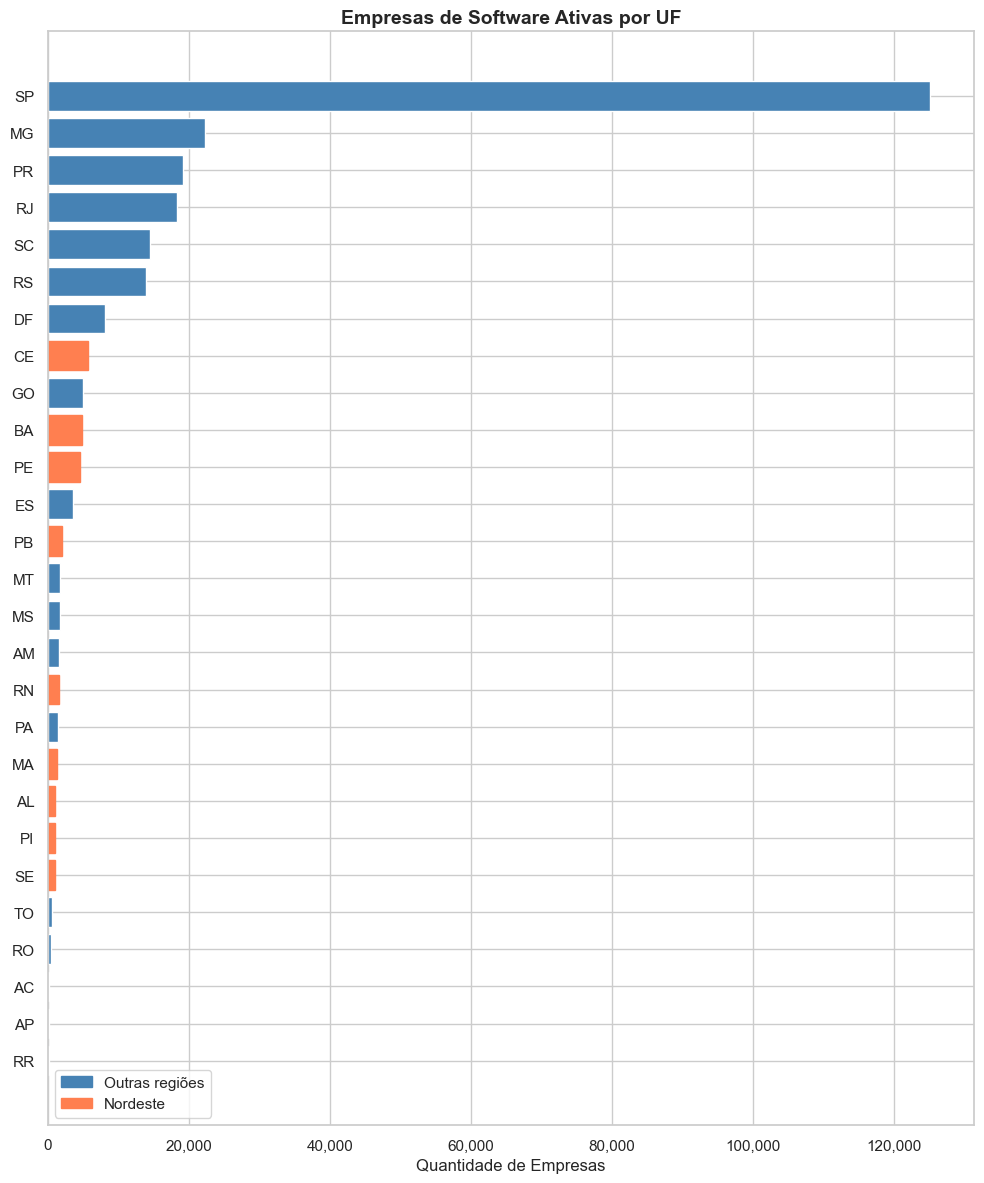

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Distribuição por UF
uf_counts = df[df['situacao_nome'] == 'Ativa']['uf'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))

bars = ax.barh(uf_counts.index, uf_counts.values, color='steelblue')

# Destaca Nordeste
nordeste = ['AL','BA','CE','MA','PB','PE','PI','RN','SE']
for bar, uf in zip(bars, uf_counts.index):
    if uf in nordeste:
        bar.set_color('coral')

ax.set_title('Empresas de Software Ativas por UF', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantidade de Empresas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Legenda
from matplotlib.patches import Patch
legend = [Patch(color='steelblue', label='Outras regiões'),
          Patch(color='coral', label='Nordeste')]
ax.legend(handles=legend)

plt.tight_layout()
plt.show()

# Cell 7 — Concentração Regional de Empresas de Software Ativas

## Visão Geral

O gráfico de concentração regional expõe de forma direta a assimetria estrutural
do setor de software brasileiro: duas regiões concentram mais de 80% das empresas
ativas enquanto o restante do país divide os 20% restantes.

---

## Distribuição por Região

| Região | % do total | Observação |
|--------|-----------|------------|
| Sudeste | 66,8% | Dois terços do setor nacional |
| Sul | 17,0% | Segunda região, menos da metade da população nordestina |
| Nordeste | 8,4% | ~28% da população, menos de 1/10 das empresas |
| Centro-Oeste | 6,1% | Inflado pelo DF (governo + empresas de tecnologia pública) |
| Norte | 1,7% | Presença quase simbólica |

---

## O Número-Chave do Projeto

O Nordeste concentra aproximadamente **28% da população brasileira** mas apenas
**8,4% das empresas de software ativas**. Isso representa uma razão de cerca de
**1:3,3** — para cada empresa de software que existiria se a distribuição fosse
proporcional à população, existe menos de uma de fato.

Esse desequilíbrio é o argumento central do **Estruture Negócios** condensado
em um único número.

---

## Comparativo Sul vs. Nordeste

O Sul (17%) tem mais que o dobro da participação do Nordeste (8,4%), apesar de
ter população consideravelmente menor. Esse contraste é especialmente relevante
porque o Sul não possui vantagens históricas de capital político ou financeiro
comparáveis ao Sudeste — sua maior participação reflete diferenças em
infraestrutura tecnológica, cultura empreendedora e acesso a mercados.

---

## Implicações para a Narrativa

A concentração no Sudeste não é apenas um dado estatístico — ela se traduz em
menor acesso a clientes, investidores, eventos, parcerias e talentos para
empreendedores como o Carlos em João Pessoa. O mercado de software brasileiro
é geograficamente centralizado em um grau que não encontra paralelo em setores
como agronegócio ou varejo.

---

## Próximos Passos

- Cruzar com dados populacionais para calcular a densidade de empresas por
  100 mil habitantes por região
- Verificar se a concentração é ainda maior quando filtrada por empresas de
  maior porte (ME, EPP) — excluindo MEIs

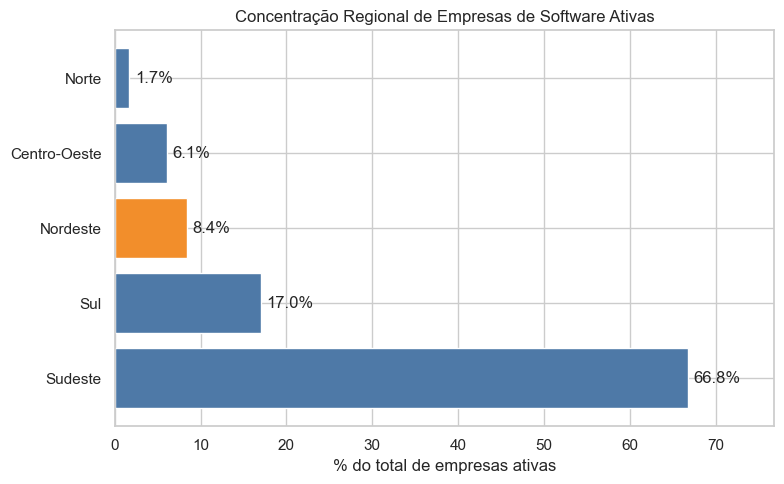

In [11]:
import matplotlib.pyplot as plt

regioes = {
    'Norte': ['AM','RR','AP','PA','TO','RO','AC'],
    'Nordeste': ['MA','PI','CE','RN','PB','PE','AL','SE','BA'],
    'Centro-Oeste': ['MT','MS','GO','DF'],
    'Sudeste': ['SP','RJ','MG','ES'],
    'Sul': ['PR','SC','RS']
}

def get_regiao(uf):
    for regiao, ufs in regioes.items():
        if uf in ufs:
            return regiao
    return 'Outro'

df['regiao'] = df['uf'].apply(get_regiao)

dist = df['regiao'].value_counts()
pct  = (dist / dist.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
cores = ['#4e79a7' if r != 'Nordeste' else '#f28e2b' for r in pct.index]
bars = ax.barh(pct.index, pct.values, color=cores)
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlabel('% do total de empresas ativas')
ax.set_title('Concentração Regional de Empresas de Software Ativas')
ax.set_xlim(0, pct.max() + 10)
plt.tight_layout()
plt.show()

# Cell 8 — Taxa de Sobrevivência por Região

## Visão Geral

A taxa de empresas ativas por região revela um resultado contraintuitivo que
desafia narrativas simplistas sobre o ecossistema de software nordestino:
empresas do Nordeste sobrevivem mais que as do Sudeste.

---

## Dados por Região

| Região | Total de empresas | % Ativas |
|--------|------------------|----------|
| Sul | 81.570 | 58,5% |
| Norte | 7.971 | 58,5% |
| Nordeste | 40.313 | 57,4% |
| Centro-Oeste | 29.381 | 56,4% |
| Sudeste | 319.836 | 52,9% |

---

## O Resultado Contraintuitivo

O Nordeste (57,4%) supera o Sudeste (52,9%) em taxa de sobrevivência. A variação
total entre todas as regiões é de apenas ~6 pontos percentuais, o que indica que
**resiliência empresarial não é o problema do ecossistema nordestino**.

---

## Por Que o Sudeste Tem a Menor Taxa?

O volume massivo de empresas em SP e RJ inclui proporcionalmente mais:
- Empresas abertas de forma oportunista ou especulativa
- Negócios de curta duração ligados a contratos pontuais
- Tentativas de empreendedorismo em mercado mais saturado e competitivo

O maior acesso a capital e infraestrutura no Sudeste também reduz a barreira de
entrada — o que gera mais tentativas, e consequentemente mais encerramentos.

---

## O Insight Central para o Projeto

O problema do ecossistema nordestino **não é que as empresas fecham mais** —
é que **poucas são abertas**. A questão é estrutural: falta de acesso a mercado,
capital, talentos e infraestrutura reduz o número de tentativas, não a qualidade
das que existem.

Esse dado quebra um possível preconceito e fortalece a narrativa do Carlos:
empreendedores nordestinos de software são tão resilientes quanto os do Sudeste,
mas operam em um ambiente com muito menos recursos e oportunidades.

---

## Próximos Passos

- Detalhar os tipos de baixa por região (encerramento voluntário vs. inapta vs.
  suspensa) para entender melhor o perfil dos encerramentos
- Verificar se a taxa de sobrevivência varia por porte da empresa dentro do Nordeste

situacao_cadastral   total  pct_ativa
regiao                               
Norte                 7971       58.5
Sul                  81570       58.5
Nordeste             40313       57.4
Centro-Oeste         29381       56.4
Sudeste             319836       52.9


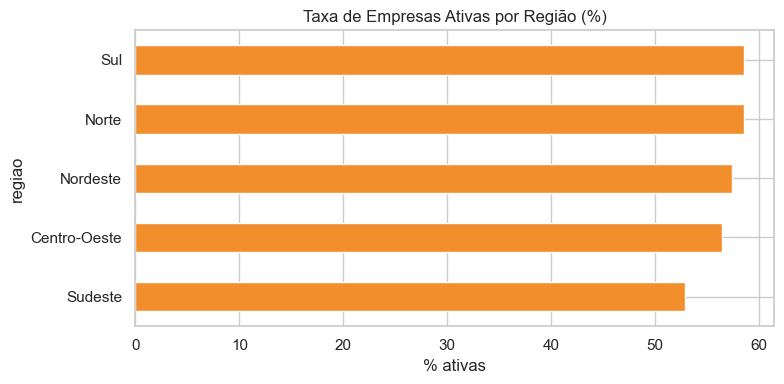

In [12]:
# situacao_cadastral: 02 = Ativa, 03 = Suspensa, 04 = Inapta, 08 = Baixada
df_todas = df.copy()  # use o df SEM filtro de situação ativa se tiver, senão ok

sobrev = df_todas.groupby(['regiao', 'situacao_cadastral']).size().unstack(fill_value=0)
sobrev['total'] = sobrev.sum(axis=1)
sobrev['pct_ativa'] = (sobrev.get(2, sobrev.get('02', 0)) / sobrev['total'] * 100).round(1)

print(sobrev[['total', 'pct_ativa']].sort_values('pct_ativa', ascending=False))

sobrev['pct_ativa'].sort_values().plot(
    kind='barh', color='#f28e2b', figsize=(8, 4),
    title='Taxa de Empresas Ativas por Região (%)'
)
plt.xlabel('% ativas')
plt.tight_layout()
plt.show()

# Cell 9 — Perfil das Empresas de Software no Nordeste

## Visão Geral

O perfil das empresas nordestinas revela um ecossistema predominantemente voltado
a serviços de baixo valor agregado e sem escala, onde o modelo de negócio dominante
é a venda de horas de trabalho — não de produto.

---

## Simples Nacional

| Regime | % |
|--------|---|
| Fora do Simples Nacional | 57,3% |
| Simples Nacional | 42,7% |

A maioria das empresas nordestinas de software está fora do Simples Nacional.
Isso pode indicar dois cenários distintos: empresas que cresceram além do teto
de faturamento do regime (R$ 4,8M/ano) ou empresas que optaram pelo Lucro
Presumido por razões tributárias. Uma análise mais aprofundada com dados de
capital social ajudaria a distinguir os dois casos.

---

## Top 8 CNAEs — O Perfil Revela o Problema

| Posição | CNAE | Tipo de negócio |
|---------|------|-----------------|
| 1º | Suporte técnico/TI | Serviço — vende hora de trabalho |
| 2º | Desenvolvimento sob encomenda | Serviço — produto para um cliente |
| 3º | Consultoria em TI | Serviço — vende conhecimento/hora |
| 4º | Software customizável | Produto — algum potencial de escala |
| 5º | Software não-customizável | Produto — maior potencial de escala |
| 6º | Web design | Serviço — baixo valor agregado |

---

## O Ecossistema de Serviço vs. Produto

O Nordeste está preso em um modelo de **serviço**, não de **produto**:

**Suporte técnico/TI** e **Consultoria em TI** juntos representam os dois maiores
grupos em volume. Empresas nessas categorias têm crescimento atrelado à contratação
de mais pessoas — não escalam de forma exponencial. Para dobrar a receita, é
preciso dobrar o time.

**Desenvolvimento sob encomenda** (2º lugar) é um modelo híbrido: tecnicamente
produz software, mas para um cliente específico, sem propriedade intelectual
própria ou receita recorrente. Também não escala.

**Software customizável e não-customizável** — as categorias com real potencial
de produto — aparecem apenas em 4º e 5º lugar, com volumes significativamente
menores que os de serviço.

---

## Implicação para a Narrativa do Carlos

O Carlos do Estruture Negócios é estatisticamente mais provável de estar no
grupo de suporte/consultoria do que desenvolvendo um produto proprietário.
Isso não é falta de capacidade técnica — é reflexo de um mercado local que
demanda serviços imediatos e não tem capital de risco para financiar a construção
de produto. O empreendedor nordestino adapta sua oferta à demanda disponível.

---

## Próximos Passos

- Comparar o mix CNAE Nordeste vs. Sudeste: o Sudeste tem proporção maior de
  software não-customizável e SaaS?
- Cruzar CNAE com capital social médio para verificar se empresas de produto
  têm maior capitalização mesmo no Nordeste

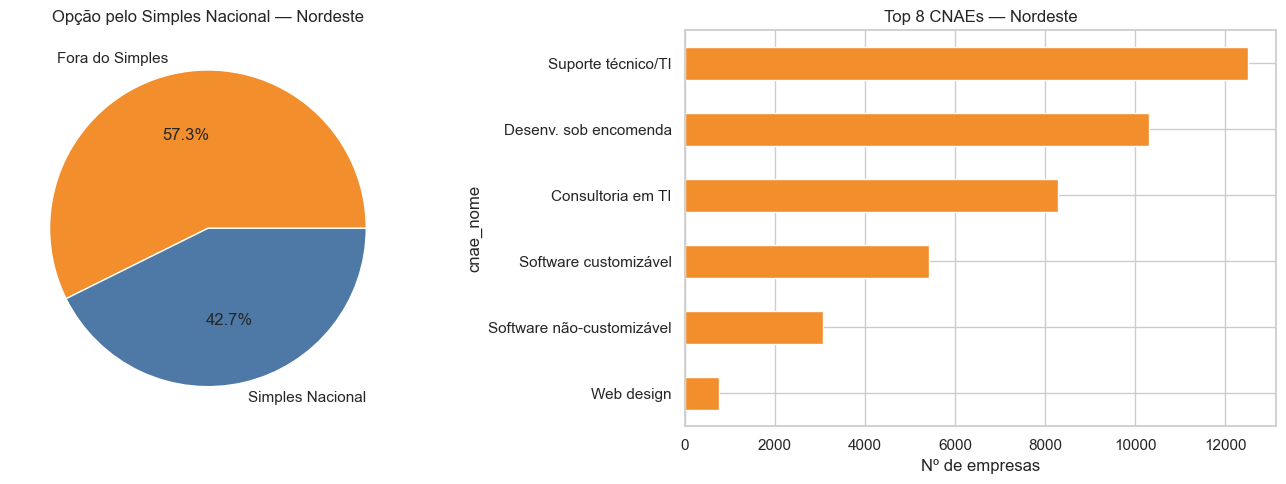

In [13]:
df_ne = df[df['regiao'] == 'Nordeste']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Porte (opcao_simples + porte implícito via capital)
simples = df_ne['opcao_simples'].value_counts()
simples.index = simples.index.map({'S': 'Simples Nacional', 'N': 'Fora do Simples'})
axes[0].pie(simples, labels=simples.index, autopct='%1.1f%%',
            colors=['#f28e2b','#4e79a7'])
axes[0].set_title('Opção pelo Simples Nacional — Nordeste')

# CNAE predominante
top_cnae = df_ne['cnae_nome'].value_counts().head(8)
top_cnae.sort_values().plot(kind='barh', ax=axes[1], color='#f28e2b')
axes[1].set_title('Top 8 CNAEs — Nordeste')
axes[1].set_xlabel('Nº de empresas')

plt.tight_layout()
plt.show()

# Cell 10 — Evolução Temporal de Abertura de Empresas por Região (2000–2025)

## Visão Geral

A série histórica de abertura de empresas de software revela que a digitalização
acelerada pós-2020 beneficiou todas as regiões — mas ampliou, e não reduziu,
a desigualdade regional absoluta.

---

## Três Períodos Distintos

### 2000–2019: Estagnação Generalizada

Todas as regiões mantiveram volumes relativamente estáveis por quase duas décadas.
O Nordeste oscilava em torno de 800 empresas abertas por ano, colado ao Norte e
Centro-Oeste. O Sudeste dominava com ~7.000–9.000 ao ano, mas também sem
crescimento expressivo. O setor de software brasileiro crescia de forma lenta
e concentrada.

### 2020: O Ponto de Inflexão

A pandemia funciona como catalisador simultâneo para todas as regiões. Três
fatores convergem:
- Digitalização forçada de negócios tradicionais aumenta a demanda por software
- Facilitação de abertura de MEI e ME reduz a barreira de entrada
- Trabalho remoto reduz (mas não elimina) a dependência de estar nos grandes centros

O resultado é um salto abrupto e sincronizado em todas as curvas a partir de 2020.

### 2020–2025: Crescimento com Gap Ampliado

O Nordeste (verde) sai de ~800 para ~5.000 empresas abertas por ano — um
crescimento real de aproximadamente 525%. O Sudeste vai de ~8.000 para ~30.000
no mesmo período — crescimento de ~275%, menor em termos relativos, mas muito
maior em termos absolutos.

---

## O Gap Está se Ampliando

| Período | Sudeste (aprox.) | Nordeste (aprox.) | Diferença absoluta |
|---------|-----------------|-------------------|-------------------|
| 2019 | ~8.000/ano | ~800/ano | ~7.200 |
| 2024 | ~21.000/ano | ~3.500/ano | ~17.500 |
| 2025 | ~30.000/ano | ~5.000/ano | ~25.000 |

A desigualdade regional **não está convergindo** na era digital — está se
aprofundando em termos absolutos. Mesmo com menos barreiras geográficas para
abertura de empresas de software, os recursos concentrados no Sudeste (capital,
clientes, talentos, acesso a investimento) continuam acelerando o crescimento
local de forma desproporcional.

---

## Atenção: Dado de 2025

O salto abrupto do Sudeste em 2025 merece verificação antes de ser usado na
narrativa. Empresas abertas muito recentemente podem ainda não ter situação
cadastral consolidada no dataset, o que poderia superestimar o volume de 2025.
Recomenda-se tratar 2025 como dado parcial nas conclusões do projeto.

---

## Implicação para o Projeto

A evolução temporal confirma que a desigualdade regional no setor de software
é **estrutural e persistente**, não um artefato histórico em processo de
correção natural. A digitalização acelerou o crescimento do setor em todo o
Brasil, mas o fez de forma desigual — reforçando a necessidade de políticas
específicas para o ecossistema nordestino que vão além da simples redução de
barreiras de entrada.

---

## Próximos Passos

- Calcular a taxa de crescimento anual composta (CAGR) por região entre 2020 e 2024
- Verificar se o crescimento nordestino pós-2020 está concentrado em CE/BA/PE
  ou se houve distribuição mais ampla entre os estados menores
- Filtrar 2025 ou tratá-lo separadamente nas análises conclusivas

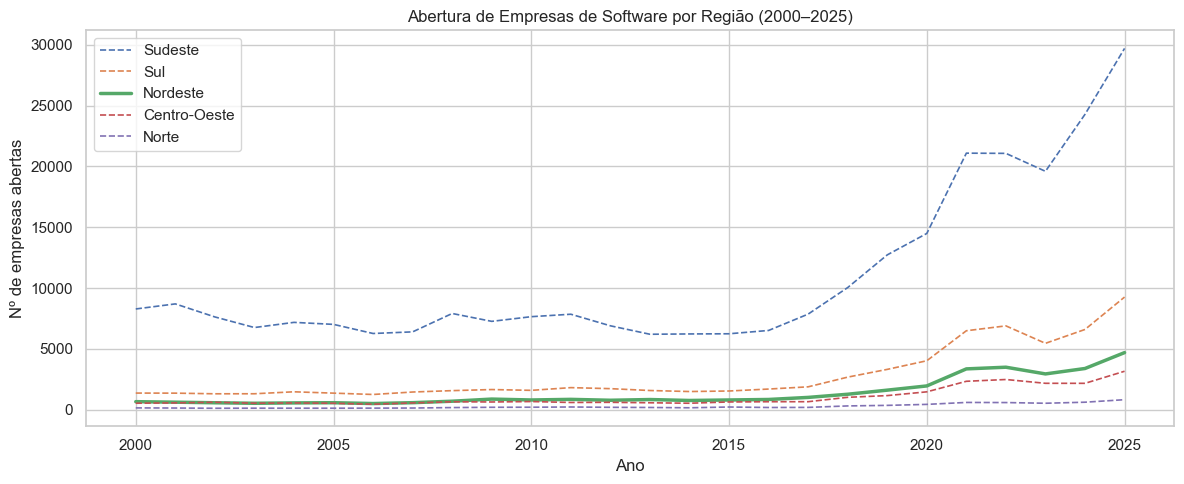

In [14]:
df['ano_abertura'] = pd.to_numeric(df['ano_abertura'], errors='coerce')
df_time = df[df['ano_abertura'].between(2000, 2025)]

evolucao = df_time.groupby(['ano_abertura', 'regiao']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
for regiao in ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte']:
    if regiao in evolucao.columns:
        lw = 2.5 if regiao == 'Nordeste' else 1.2
        ls = '-' if regiao == 'Nordeste' else '--'
        ax.plot(evolucao.index, evolucao[regiao], label=regiao, linewidth=lw, linestyle=ls)

ax.set_title('Abertura de Empresas de Software por Região (2000–2025)')
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de empresas abertas')
ax.legend()
plt.tight_layout()
plt.show()